# Apply OE

Apply OE is the built-in end-to-end atmospheric correction pipeline, and is the easiest way to run Isofit. Apply OE is run via a command line interface (CLI) tool accessed with a terminal call:

```bash
isofit apply_oe --help
```

The function docstring is printed when this command is run within a terminal window, and acts as a guide for how to run the function.

In [1]:
from isofit.utils.apply_oe import apply_oe

print(apply_oe.__doc__)


Applies OE over a flightline using an atmospheric radiative transfer engine. This executes
ISOFIT in a generalized way, accounting for the types of variation that might be
considered typical.

Observation (obs) and location (loc) files are used to determine appropriate
geometry lookup tables and provide a heuristic means of determining atmospheric
water ranges.

Parameters
----------
input_radiance : str
    Radiance data cube. Expected to be ENVI format
input_loc : str
    Location data cube of shape (Lon, Lat, Elevation). Expected to be ENVI format
input_obs : str
    Observation data cube of shape:
        (path length, to-sensor azimuth, to-sensor zenith,
        to-sun azimuth, to-sun zenith, phase,
        slope, aspect, cosine i, UTC time)
    Expected to be ENVI format
working_directory : str
    Directory to stage multiple outputs, will contain subdirectories
sensor : str
    The sensor used for acquisition, will be used to set noise and datetime
    settings
surface_path : s

The Apply OE function can leverage a large number of input parameters, but most are optional. The important inputs are the non-optional arguments:

`INPUT_RADIANCE` `INPUT_LOC` `INPUT_OBS` `WORKING_DIRECTORY` `SENSOR` and `--surface_path`.

which must be entered in the specified order (except `--surface_path` which can be added at any point but still required). Descriptions of each are found in the docstring printed above. It is important to note that the `INPUT_RADIANCE`, `INPUT_LOC`, and `INPUT_OBS` are ENVI raster data formats that must be at the same row-column dimensions. The `--surface_path` points Isofit towards the constructed prior distribution file for surface reflectance. Optional arguments are denoted by the '--' in their name, e.g.  `--modtran_path`, `--pressure_elevation`. It is important to note that the default radiative transfer engine (RTE) is currently set to sRTMnet, set via `--emulator_path`.


#### `INPUT_RADIANCE`
The data is at-sensor radiance in units of $\mu W \, cm^{-2} \, nm^{-1} \, sr^{-1} $. You may leverage **[isofit.core.units](https://isofit.github.io/isofit/latest/api/isofit/core/units/#isofit.core.units)** module which offers many common conversions. The .hdr file should be used to store the wavelength and fwhm. 


#### `INPUT_LOC`

1. **Longitude [degrees]**
    - Range is -180 to 180

2. **Latitude [degrees]**
    - Range is -90 to 90

3. **Elevation [meters]**
    - Above mean sea level 



#### `INPUT_OBS`

Note: the names of the keys do not need to match exactly, only the order matters.

1. **Path length [meters]**
    - Defined as the slant path from the sensor to the surface

2. **To-sensor azimuth, $\phi_v$ [degrees]**
    - Ranges from 0-360, measured clockwise from north

3. **To-sensor zenith, $\theta_v$ [degrees]**
    - Ranges from 0-90, measured from zenith

4. **To-sun azimuth, $\phi_s$ [degrees]**
    - Ranges from 0-360, measured clockwise from north

5. **To-sun zenith, $\theta_s$ [degrees]**
    - Ranges from 0-90, measured from zenith

6. **Phase angle, $\xi$ [degrees]**
    - $cos(\xi) = cos(\theta_s) \, cos(\theta_v) \, + \, sin(\theta_s) \, sin(\theta_v) \, cos(\phi_s - \phi_v)$
    - $\xi = arccos(cos(\xi))$

7. **Slope, $S$ [degrees]**
    - Ranges from 0-90

8. **Aspect, $A$ [degrees]**
    - Ranges from 0-360, measured clockwise from north

9. **Cosine of the local solar illumination angle, $cos(i)$ [unitless]**
    - $cos(i) = cos(\theta_s) \, cos(S) \, + \, sin(\theta_s) \, sin(S) \, cos(\phi_s - A) $

10. **UTC time [decimal]**
    - Ranges from 0 - 24

11. **Earth-sun distance [AU]**
    - Astronomical Unit as a function of day of year

## How do you run Apply OE?

The script is run via the CLI. For example:

> `IC=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/small_example` sets the environment variable `IC` to the output of the command `isofit path path_to/EARSeL_ISOFIT_tutorial/small_example`. This is just used to reuse the same output for multiple arguments. Simply replace `path_to` by your local path where you saved the ISOFIT tutorial material.
> Depending on the user's isofit installation environment, this path may vary. This command ensures the correct path is retrieved

```bash
  IC=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/small_example EX=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/small_example \
  isofit apply_oe \
  $IC/path_to_rdn_img \
  $IC/path_to_loc_img \
  $IC/path_to_obs_img \
  $EX \
  enmap \
  --surface_path $IC/surface_20240103_enmap.mat \
  --emulator_base $(isofit path srtmnet --key file) \
  --n_cores 10 \
  --presolve \
  --log_file $EX/log.txt
```

Here,

```
$IC/path_to_rdn_img
$IC/path_to_loc_img
$IC/path_to_obs_img
```

are the radiance, location, and observational geometry files respectively. The `\` tells the CLI call to expect a multi-line input. The remaining two required parameters are `enmap`, the sensor designation (EnMAP), and the `--surface_path` pointing to the surface configuration file.

The remaining arguments set Apply OE to run with:
1) `--emulator_base` points isofit to the location of the sRTMnet emulator to usse as the radiative transfer engine (RTE)
2) `--n_cores = 10` CPU cores
3) The `--presolve` algorithm to narrow down the water vapor retrievals
4) The `--log_file` points the program to write a text file to print logging statements during run time.

In the following, we use two subsets each of three EnMAP images to demonstrate both the pixelwise and segmentation-based inversion. Feel free to run one or more from these three examples, each featuring specific geographic locations and surface types. EnMAP L1C products used in this tutorial can be downloaded from https://www.enmap.org/data_tools/exampledata/. The notebook `convert_EnMAP_to_ENVI.ipynb` shows how to transform EnMAP Geotiff files into ENVI binary format, and how to create subsets of the images as used in this tutorial.

In [2]:
# Tyrol, Austria: Snow and Vegetation
fid = "ENMAP01-____L1C-DT0000001049_20220612T105735Z_028_V010303_20230922T131826Z"
name = "Tyrol"

# Groningen, Netherlands: Coastal Ocean and Agriculture
# fid = "ENMAP01-____L1C-DT0000002446_20220810T112429Z_002_V010303_20230922T131813Z"
# name = "Groningen"

# Nevada, USA: Soil and Minerals
# fid = "ENMAP01-____L1C-DT0000025905_20230707T192008Z_001_V010303_20230922T131737Z"
# name = "Nevada"

timestamp = fid[29:45]

First, we look at the full radiance RGB:

In [3]:
# Common imports

import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from spectral import envi

from isofit.data import env
from isofit.core.common import envi_header
from isofit.utils import surface_model
from isofit.utils.reconstruct import reconstruct_subs

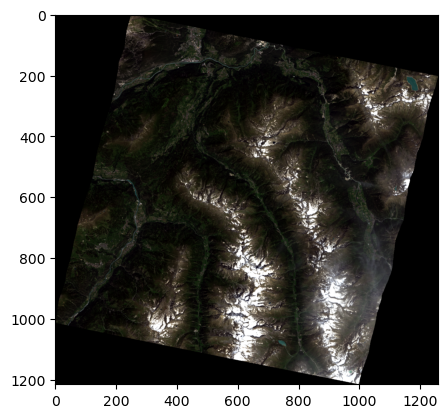

In [4]:
plt.imshow(Image.open(f"../remote/{fid}_rdn.png"))

In [5]:
# In the following, we want to call apply_oe programatically. If you prefer to execute apply_oe via the command line above, feel free to do so instead.
# We use the env object to retrieve the actual location of the ISOFIT extra dependencies instead of assuming where they could be.

# Path to tutorial material, replace by your own respective directory
tutorial_path = "/Users/bohn/Desktop/Conferences/EARSeL_2026/Tutorial/EARSeL_ISOFIT_tutorial"

# Path to ISOFIT output
output = f"{tutorial_path}/small_example/{name}"

# Cleanup any previous runs; comment this out if you want to preserve a previous run's output
if (os.path.exists(output + "/output")):
    o = os.path.abspath(output + "/output")
    shutil.rmtree(o)

# Surface model
# One option to build it
# We don't execute this, but this would be the way to build the .mat file
# surface_model("surface_20240103_enmap.json")

# Input rdn, loc, obs files
# The notebook convert_EnMAP_to_ENVI.ipynb provides an example of how to convert EnMAP L1 radiance to ENIV binary format

apply_oe(
    input_radiance    = f"{tutorial_path}/small_example/{name}/" + f"{fid}_rdn_sub_small.img",
    input_loc         = f"{tutorial_path}/small_example/{name}/" + f"{fid}_loc_sub_small.img",
    input_obs         = f"{tutorial_path}/small_example/{name}/" + f"{fid}_obs_sub_small.img",
    working_directory = output,
    sensor            = "enmap",
    surface_path      = tutorial_path + "/surface_20240103_enmap.mat",
    emulator_base     = str(env.path("srtmnet", key="srtmnet.file")),
    presolve          = True,
    n_cores           = os.cpu_count(),
    log_file          = f"{tutorial_path}/small_example/{name}/log.txt",
)

/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
2026-06-05 11:29:36,354	INFO worker.py:2012 -- Started a local Ray instance.
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._m

We can now examine both the inputs and outputs of Apply OE with this run call:

In [6]:
# Load the input files
rdn_path = f"small_example/{name}/{fid}_rdn_sub_small.hdr"
loc_path = f"small_example/{name}/{fid}_loc_sub_small.hdr"
obs_path = f"small_example/{name}/{fid}_obs_sub_small.hdr"

rdn = envi.open(envi_header(str(rdn_path)))
loc = envi.open(envi_header(str(loc_path)))
obs = envi.open(envi_header(str(obs_path)))

rdn_im = rdn.open_memmap(interleave='bip')
loc_im = loc.open_memmap(interleave='bip')
obs_im = obs.open_memmap(interleave='bip')

In [7]:
# Print the bands of the input files
print('Band names in the location file:')
[print(f"{i}") for i in loc.metadata['band_names']]

print()
print('Band names in the observational geometry file:')
temp = [print(f"{i}") for i in obs.metadata['band_names']]

Band names in the location file:
Longitude (WGS-84)
Latitude (WGS-84)
Elevation (m)

Band names in the observational geometry file:
Path length (m)
To-sensor azimuth (0 to 360 degrees CW from N)
To-sensor zenith (0 to 90 degrees from zenith)
To-sun azimuth (0 to 360 degrees CW from N)
To-sun zenith (0 to 90 degrees from zenith)
Solar phase
Slope
Aspect
Cosine(i)
UTC Time
Earth-sun distance (AU)


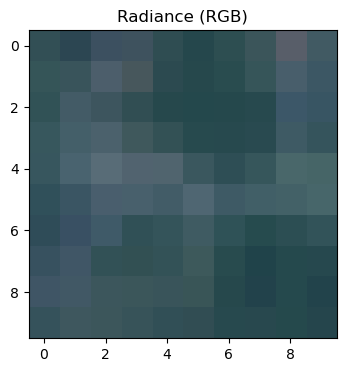

In [8]:
# Plot the input data
normalize = lambda x, vmin, vmax:  (x - vmin) / (vmax - vmin)
bands = [44, 29, 12]

fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(14, 4))
# Depending on the input image you need to scale vmin and vmax values
# Tyrol: (0,15)
# Groningen: (3.5,4.0)
# Nevada: (5,10)
plot = axs.imshow(normalize(rdn_im[..., bands], 0,15))

title = axs.set_title('Radiance (RGB)')

The input image doesn't look like much because this is just a 10x10 pixel example. However we see a slight per-pixel variation in the radiance RGB. 

In [9]:
# Load the output files
rfl_path = f"small_example/{name}/output/{timestamp}_rfl.hdr"
state_path = f"small_example/{name}/output/{timestamp}_state.hdr"
uncert_path = f"small_example/{name}/output/{timestamp}_uncert.hdr"

rfl = envi.open(envi_header(str(rfl_path)))
state = envi.open(envi_header(str(state_path)))
uncert = envi.open(envi_header(str(uncert_path)))

rfl_im = rfl.open_memmap(interleave='bip')
state_im = state.open_memmap(interleave='bip')
uncert_im = uncert.open_memmap(interleave='bip')

print(f'Shape of the _rfl file: {rfl_im.shape}')
print(f'Shape of the _state file: {state_im.shape}')
print(f'Shape of the _uncert file: {uncert_im.shape}')

Shape of the _rfl file: (10, 10, 224)
Shape of the _state file: (10, 10, 226)
Shape of the _uncert file: (10, 10, 226)


The difference between the `_rfl` file and the `_state` file is that the `_rfl` file only contains the solutions for surface reflectance variables. Here, the EnMAP image contains 224 wavelength bands. As a result, the `_rfl` contains 224 bands. The `_state` and `_uncert` files contain the surface reflectance solutions and uncertainty calculated as the standard deviation of the posterior distributions for the 224 wavelength bands and for non-reflectance statevector elements; here, aerosol optical depth (AOD) and water vapor (H2O).

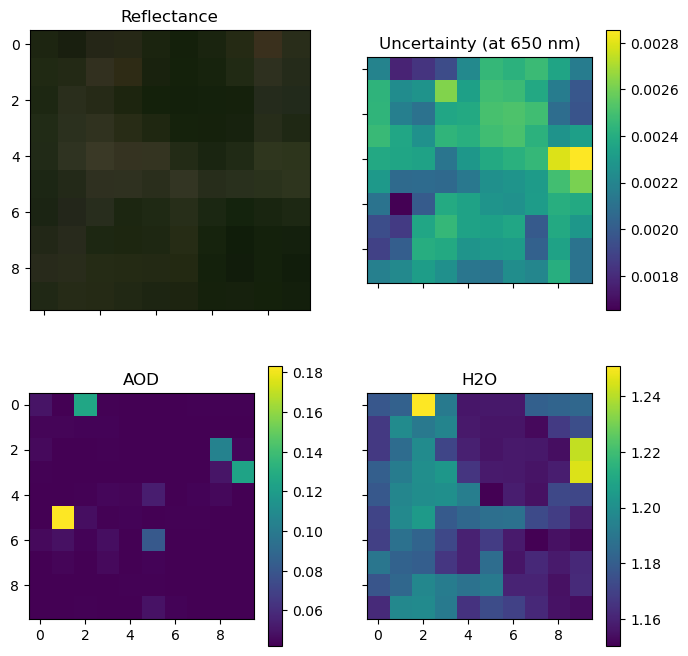

In [10]:
# Plot the output data
normalize = lambda x, vmin, vmax:  (x - vmin) / (vmax - vmin)
bands = [44, 29, 12]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(8, 8))
axs = np.ravel(axs)
# Depending on the input image you need to scale vmin and vmax values
# Tyrol: (0.0,0.5)
# Groningen: (0.05,0.1)
# Nevada: (0,0.3)
plot = axs[0].imshow(normalize(rfl_im[..., bands], 0, 0.5))
uncert = axs[1].imshow(uncert_im[..., 55])
aod = axs[2].imshow(state_im[..., -2])
h2o = axs[3].imshow(state_im[..., -1])

plt.colorbar(uncert)
plt.colorbar(aod)
plt.colorbar(h2o)

title = axs[0].set_title('Reflectance')
title = axs[1].set_title('Uncertainty (at 650 nm)')
title = axs[2].set_title('AOD')
title = axs[3].set_title('H2O')

We can also inspect the retrieved surface reflctance spectrally.

Text(0, 0.5, 'Reflectance')

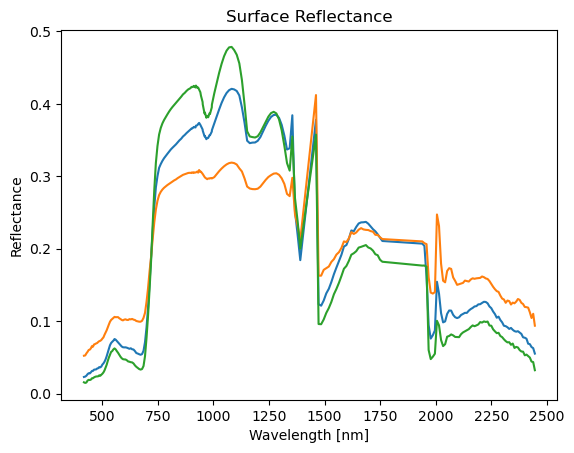

In [11]:
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[0,0,:])
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[5,5,:])
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[-1,-1,:])
plt.title("Surface Reflectance")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reflectance")

## The Analytical Line

In the example above, we ran Isofit using the full optimal estimation (OE) on each pixel independently. Computationally, this amounts to iterating through each row-column pair to solve for the full state-vector (226 variables in the above case). However for large images, this demands long run-times, and ignores the principle that some state-vector elements, namely the atmospheric variables like AOD and H2O, should not vary from one pixel to another, but rather should be spatially smooth, and only vary over multi-pixel length scales [Link to the relevent paper](https://doi.org/10.1016/j.rse.2023.113902).

The analytical line and empirical line algorithms leverage the assumption of a spatially smooth atmosphere to decrease run times by a factor of 10. Currently, we suggest using the analytical line algorithm and not the empirical line algorithm.

See the following CLI call to run Apply OE with the analytical line algorithm:

```bash
  IC=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/medium_example EX=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/medium_example \
  isofit apply_oe \
  $IC/path_to_rdn_img \
  $IC/path_to_loc_img \
  $IC/path_to_obs_img \
  $EX \
  enmap \
  --surface_path $IC/surface_20240103_enmap.mat \
  --emulator_base $(isofit path srtmnet --key file) \
  --n_cores 10 \
  --presolve \
  --analytical_line \
  --segmentation_size 50 \
  --log_file $EX/log.txt
```

Most of the input parameters are identical to the per-pixel application above. However, we've added the `--analytical_line` flag and a `--segmentation_size`.  The `--analytical_line` flag tells Isofit to use the analytical line algorithm.

A simple overview for the anylitical line algorithm:

1) All three input files are "segmented" into superpixel blocks using the SLIC algorithm. The  `--segmentation_size` value sets the number of pixels that each superpixel contains.

2) At the superpixel resolution, Isofit solves for the OE solutions, which provides both surface and atmospheric state variables.

3) Atmospheric state variables are spatially interpolated to full image resolution. The spatial interpolation uses the Apply OE parameters `--num_neighbors` and `--atm_sigma`.

4) With a fixed atmosphere, we leverage a closed form solution for surface state elements that allows for a solution convergence in a single iteration.

In [12]:
# In the following, we want to call apply_oe programatically. If you prefer to execute apply_oe via the command line above, feel free to do so instead.
# We use the env object to retrieve the actual location of the ISOFIT extra dependencies instead of assuming where they could be.

# Path to ISOFIT output
output = f"{tutorial_path}/medium_example/{name}"

# Cleanup any previous runs; comment this out if you want to preserve a previous run's output
if (os.path.exists(output + "/output")):
    o = os.path.abspath(output + "/output")
    shutil.rmtree(o)

apply_oe(
    input_radiance    = f"{tutorial_path}/medium_example/{name}/" + f"{fid}_rdn_sub_medium.img",
    input_loc         = f"{tutorial_path}/medium_example/{name}/" + f"{fid}_loc_sub_medium.img",
    input_obs         = f"{tutorial_path}/medium_example/{name}/" + f"{fid}_obs_sub_medium.img",
    working_directory = output,
    sensor            = "enmap",
    surface_path      = tutorial_path + "/surface_20240103_enmap.mat",
    emulator_base     = str(env.path("srtmnet", key="srtmnet.file")),
    presolve          = True,
    n_cores           = os.cpu_count(),
    analytical_line   = True,
    segmentation_size = 50,
    log_file          = f"{tutorial_path}/medium_example/{name}/log.txt",
)

2026-06-05 11:35:54,507	INFO worker.py:2012 -- Started a local Ray instance.
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
2026-06-05 11:35:59,687	INFO worker.py:1828 -- Calling ray.init() again after it has already been called.
/Users/bohn/mambaforge/envs/isofit_test_env/lib/python3.13/site-packages/isofit/atmosphere/atmosphere.py:549: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'point'} to avoid an error in the future.
  ds[term] = ds[key1] * ds[key2]
I0000 00:00:1780648560.619190  314040 chttp2_transport.cc:1182] ipv4:127.0.

We can visualize what the segmentation is doing by leveraging the `isofit reconstruct_subs` CLI command:

```bash
EX=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/medium_example isofit reconstruct_subs \
    $EX/input/path_to_subs_rdn \
    $EX/input/path_to_subs_recon_rdn \
    $EX/output/path_to_lbl

EX=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/medium_example isofit reconstruct_subs \
    $EX/input/path_to_subs_loc \
    $EX/input/path_to_subs_recon_loc \
    $EX/output/path_to_lbl

EX=$(isofit path) path_to/EARSeL_ISOFIT_tutorial/medium_example isofit reconstruct_subs \
    $EX/input/path_to_subs_obs \
    $EX/input/path_tosubs_recon_obs \
    $EX/output/path_to_lbl
```

In [13]:
for product in ("rdn", "loc", "obs"):
    reconstruct_subs(
        input_subs_path  = f"{tutorial_path}/medium_example/{name}/input/" + f"{timestamp}_subs_{product}",
        output_path      = f"{tutorial_path}/medium_example/{name}/input/" + f"{timestamp}_subs_recon_{product}",
        lbl_working_path = f"{tutorial_path}/medium_example/{name}/output/{timestamp}_lbl",
    )

Visualizing the input data:

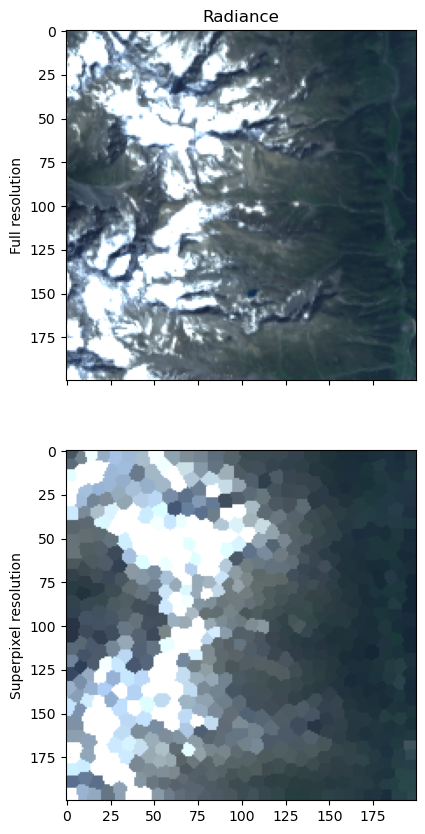

In [14]:
# Plotting the input data
rdn_path = f"medium_example/{name}/{fid}_rdn_sub_medium.hdr"

subs_rdn_path = f"{tutorial_path}/medium_example/{name}/input/{timestamp}_subs_recon_rdn.hdr"

rdn = envi.open(envi_header(str(rdn_path)))

subs_rdn = envi.open(envi_header(str(subs_rdn_path)))

rdn_im = rdn.open_memmap(interleave='bip')

subs_rdn_im = subs_rdn.open_memmap(interleave='bip')

fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(10, 10))
axs = np.ravel(axs)
# Depending on the input image you need to scale vmin and vmax values
# Tyrol: (0,20)
# Groningen: (0,10)
# Nevada: (0,20)
axs[0].imshow(normalize(rdn_im[:, :, bands], 0, 20))
axs[1].imshow(normalize(subs_rdn_im[:, :, bands], 0, 20))
axs[0].set_title('Radiance')
axs[0].set_ylabel('Full resolution')
axs[1].set_ylabel('Superpixel resolution')
plt.show()

We can examine the results from Apply OE after the OE solutions on the superpixels:

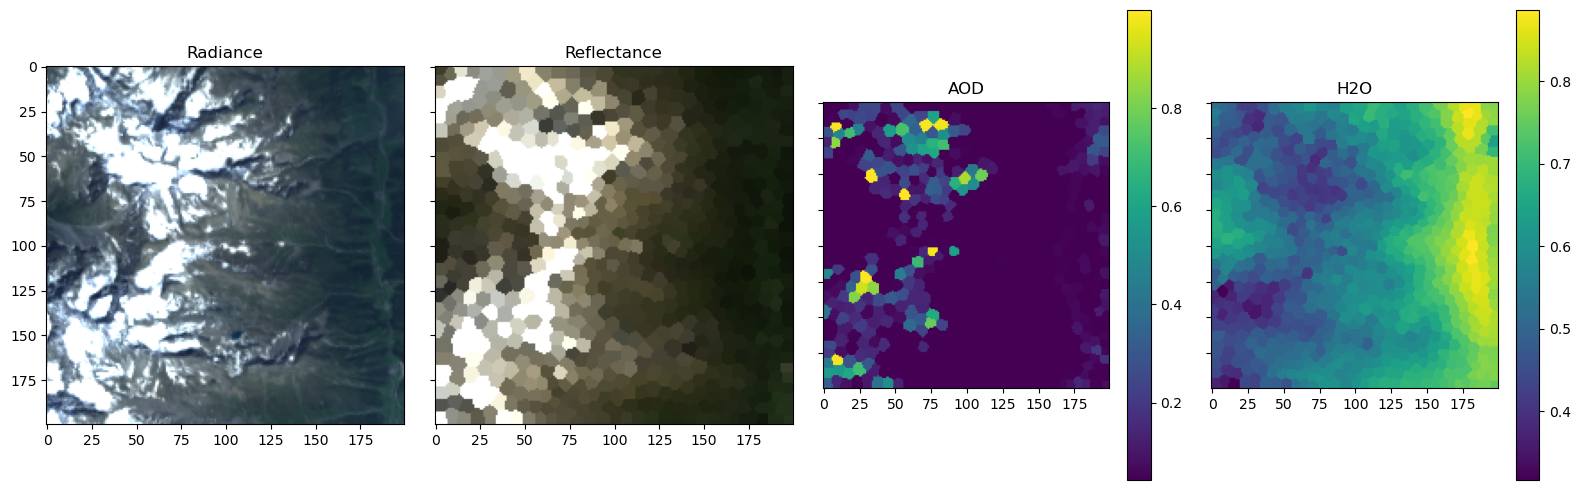

In [15]:
state_path = f"{tutorial_path}/medium_example/{name}/input/{timestamp}_subs_recon_state.hdr"

reconstruct_subs(
    input_subs_path  = f"{tutorial_path}/medium_example/{name}/output/{timestamp}_subs_state.hdr",
    output_path      = state_path,
    lbl_working_path = f"{tutorial_path}/medium_example/{name}/output/{timestamp}_lbl",
)

state = envi.open(envi_header(str(state_path)))
state_im = state.open_memmap(interleave='bip')

fig, axs = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(16, 5), tight_layout=True)
# Depending on the input image you need to scale vmin and vmax values
# Tyrol: (0,20); (0,0.5)
# Groningen: (0,10); (0,0.2)
# Nevada: (0,20); (0,0.4)
axs[0].imshow(normalize(rdn_im[:, :, bands], 0, 20))
axs[1].imshow(normalize(state_im[:, :, bands], 0, 0.5))
aod = axs[2].imshow(state_im[:, :, -2])
h2o = axs[3].imshow(state_im[:, :, -1])

plt.colorbar(aod)
plt.colorbar(h2o)

axs[0].set_title('Radiance')
axs[1].set_title('Reflectance')
axs[2].set_title('AOD')
axs[3].set_title('H2O')
plt.show()

Finally, we can examine the final results at the end of the anlaytical line algorithm. We now see much more structure and surface type variation as we are looking at a larger subset of the EnMAP image.

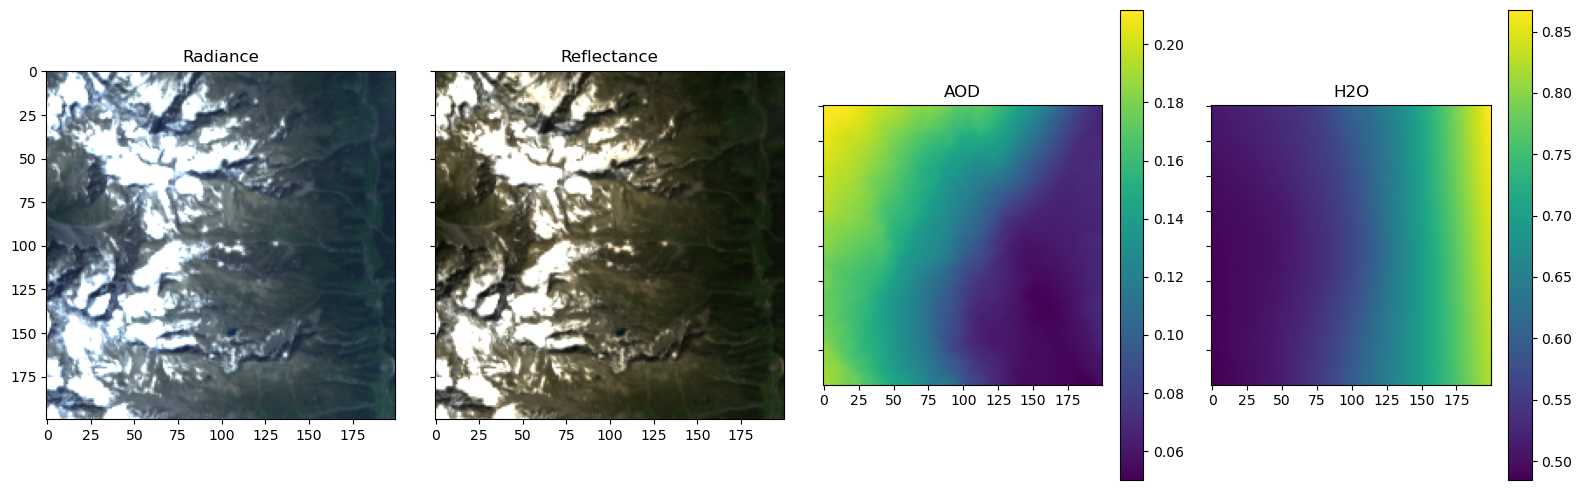

In [16]:
rfl_path = f"{tutorial_path}/medium_example/{name}/output/{timestamp}_rfl.hdr"
atm_path = f"{tutorial_path}/medium_example/{name}/output/{timestamp}_atm_interp.hdr"

rfl  = envi.open(envi_header(str(rfl_path)))
atm  = envi.open(envi_header(str(atm_path)))

rfl_im = rfl.open_memmap(interleave='bip')
atm_im = atm.open_memmap(interleave='bip')


fig, axs = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(16, 5), tight_layout=True)
# Depending on the input image you need to scale vmin and vmax values
# Tyrol: (0,20); (0,0.5)
# Groningen: (0,10); (0,0.2)
# Nevada: (0,20); (0,0.4)
axs[0].imshow(normalize(rdn_im[:, :, bands], 0, 20))
axs[1].imshow(normalize(rfl_im[:, :, bands], 0, 0.5))
aod = axs[2].imshow(atm_im[:, :, -2])
h2o = axs[3].imshow(atm_im[:, :, -1])

plt.colorbar(aod)
plt.colorbar(h2o)

axs[0].set_title('Radiance')
axs[1].set_title('Reflectance')
axs[2].set_title('AOD')
axs[3].set_title('H2O')
plt.show()

And we can of course inspect the retrieved surface reflctance again.

Text(0, 0.5, 'Reflectance')

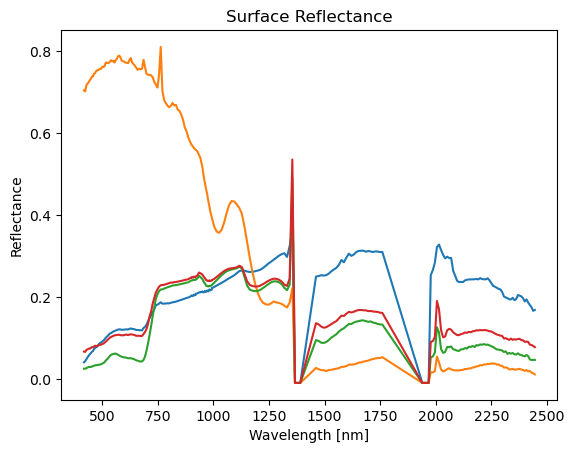

In [17]:
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[0,0,:])
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[-1,0,:])
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[0,-1,:])
plt.plot(np.array(rfl.metadata["wavelength"], dtype=float), rfl_im[-1,-1,:])
plt.title("Surface Reflectance")
plt.xlabel("Wavelength [nm]")
plt.ylabel("Reflectance")